# Exploratory Data Analysis: Depression

This notebook contains the EDA for the variable of interest: `has_depression`.

## 1. Summary of findings:

- ~78% of respondents do not report any (previous) depression, 21% do.
- Potential predictor variables relating to mental, pysical, and overall health provide limited insight into their relationship with reported depression at first glace.
    - This is due an often very uneven distribution of responses in these predictors, where values such as 0 days of poor physical/mental/overall health jump out heavily
    - *An interesting tangential finding from these variables is that responses outside of 0 or low values seem to bunch to numbers that are easy to calculate fractions of the month (e.g. 10, 15, 20)*
- Another potential issue with predicting depression could be the way the data on it was collected. The question asked to respondents was – *(Ever told) (you had) a depressive disorder (including depression, major depression, dysthymia, or minor depression)?* – This means that data on depression could include both current or previous depression, making it harder to simply predict depression.
- **If we chose to do any application including depression as a dependent variable we have to make sure to phrase our questions very carefully to account for how data on depression was collected.**
    - It could still be interesting to apply a kernel approach to this variable, however the size of our data probably limits such an approach.

In [1]:
# ––––––– Setup –––––––
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/subsets/brfss2024_subset.parquet")

In [2]:
# ––––––– Basics and summary statistics –––––––
display(df['has_depression'].describe(percentiles = [i/10 for i in range(1, 10)]))

print(f'Number of missing values for `has_depression`: {df['has_depression'].isnull().sum()}')

df.dropna(subset = ['has_depression'], inplace = True)

count    457665.000000
mean          1.821608
std           0.595446
min           1.000000
10%           1.000000
20%           1.000000
30%           2.000000
40%           2.000000
50%           2.000000
60%           2.000000
70%           2.000000
80%           2.000000
90%           2.000000
max           9.000000
Name: has_depression, dtype: float64

Number of missing values for `has_depression`: 5


Label for `has_depression`: *(Ever told) you had a depressive disorder*

Question: *(Ever told) (you had) a depressive disorder (including depression, major depression, dysthymia, or minor depression)?*

|   Value   |   Meaning     |
|-----------|---------------|
|   **1**       |   **Yes**         |
|   **2**       |   **No**          |
|   7       |   Don't know/Not sure  |
|   9       |   Refused     |

The entire dataset only contains 5 entries with a missing value for this variable which is an insignificant amount, we drop these observations.

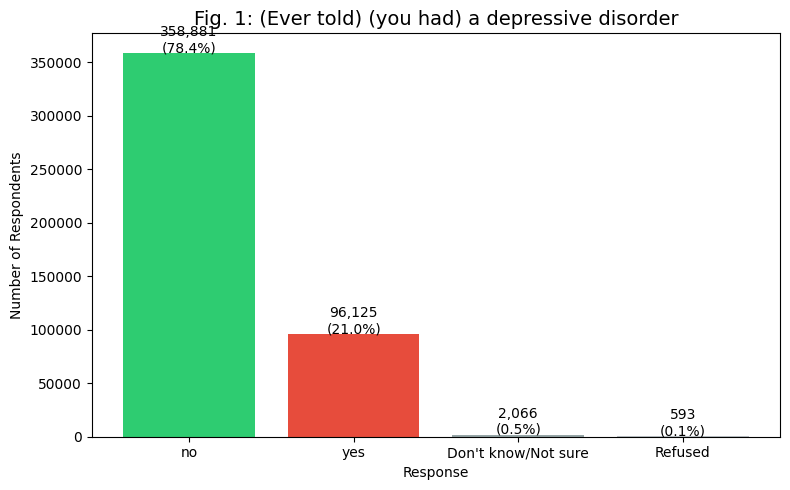

In [3]:
# ––––––– Response distribution –––––––

depression_labels = {
    1: "yes",
    2: "no",
    7: "Don't know/Not sure",
    9: "Refused"
}

depression_nums = df['has_depression'].map(depression_labels).value_counts()
depression_percentages = df['has_depression'].map(depression_labels).value_counts(normalize = True) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(depression_nums.index, depression_nums.values, color = ['#2ecc71', '#e74c3c', '#95a5a6', '#bdc3c7'])

# Add count + percentage labels on bars
for bar, pct in zip(bars, depression_percentages.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{bar.get_height():,.0f}\n({pct:.1f}%)',
            ha='center', fontsize=10)

ax.set_title('Fig. 1: (Ever told) (you had) a depressive disorder', fontsize=14)
ax.set_ylabel('Number of Respondents')
ax.set_xlabel('Response')
plt.tight_layout()
plt.show()

## 2. Explanatory variables of interest (general categories, underlying specifics for later)

#### Mental health:
- `days_poor_mental_health`: In the last thirty days; 1-30, 88 if none, 77 if don't know, 99 if refused
- `life_satisfaction`: 1-4 very satisfied to very dissatisfied, 7 don't know, 9 refused
- `emotional_support_freq`: How often do you get the emotional support needed: 1-5 always to never (7 don't know, 9 refused)
- `loneliness_freq`: How often do you feel lonely: 1-5 always to never (7 don't know, 9 refused)

#### Health status: 
- `general_health`: 1-5 excellent to poor, (7 don't know, 9 refused)
- `days_poor_physical_health`: In the last thirty days; 1-30, 88 if none, 77 if don't know, 99 if refused
- `days_poor_health_overall`:  In the last thirty days; 1-30, 88 if none, 77 if don't know, 99 if refused

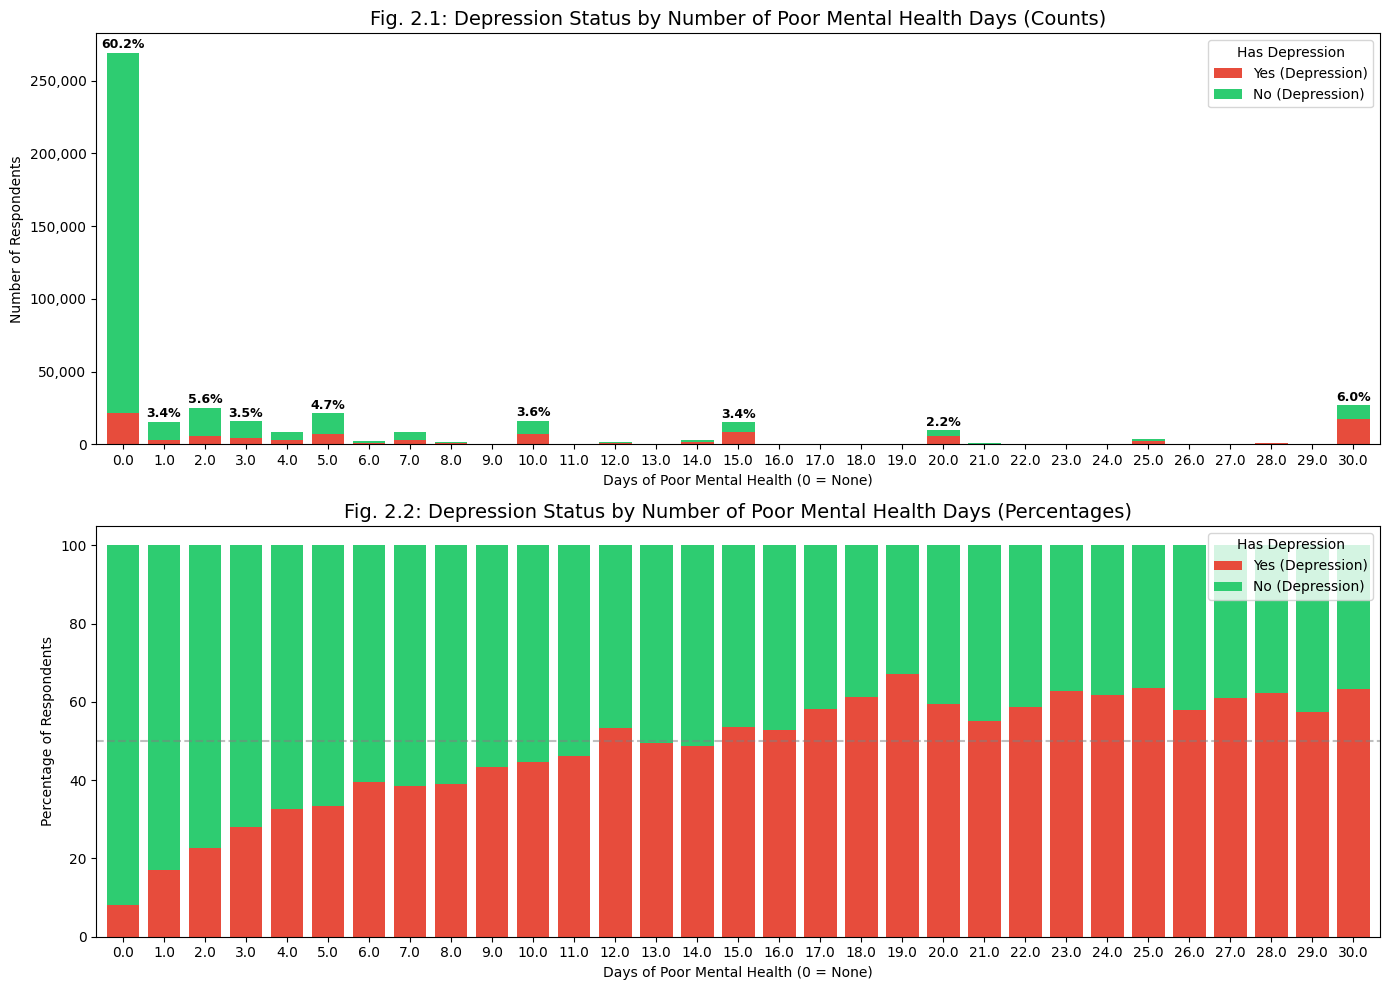

In [4]:
# ––––––– Days poor mental health subplots –––––––

# Filter to valid responses only (1-30 days or 88 for none)
valid_mental_health = df[df['days_poor_mental_health'].isin(list(range(1, 31)) + [88])].copy()

# Map 88 to 0 for "none" days
valid_mental_health['days_poor_mental_health'] = valid_mental_health['days_poor_mental_health'].replace(88, 0)

# Filter to valid depression responses (1 = Yes, 2 = No)
valid_mental_health = valid_mental_health[valid_mental_health['has_depression'].isin([1, 2])]

# Create crosstabs
crosstab_counts = pd.crosstab(
    valid_mental_health['days_poor_mental_health'], 
    valid_mental_health['has_depression']
)
crosstab_pct = pd.crosstab(
    valid_mental_health['days_poor_mental_health'], 
    valid_mental_health['has_depression'],
    normalize='index'
) * 100

# Rename columns for clarity
crosstab_counts.columns = ['Yes (Depression)', 'No (Depression)']
crosstab_pct.columns = ['Yes (Depression)', 'No (Depression)']

# Sort by index (days)
crosstab_counts = crosstab_counts.sort_index()
crosstab_pct = crosstab_pct.sort_index()

# Calculate total responses and percentage for each day value
total_responses = crosstab_counts.sum(axis=1)
pct_of_total = (total_responses / total_responses.sum()) * 100

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Counts
crosstab_counts.plot(
    kind='bar', 
    stacked=True, 
    ax=ax1, 
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax1.set_title('Fig. 2.1: Depression Status by Number of Poor Mental Health Days (Counts)', fontsize=14)
ax1.set_xlabel('Days of Poor Mental Health (0 = None)')
ax1.set_ylabel('Number of Respondents')
ax1.legend(title='Has Depression', loc='upper right')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add percentage labels to significant columns (e.g., >= 2% of total)
threshold = 2.0
for i, (day, pct) in enumerate(pct_of_total.items()):
    if pct >= threshold:
        count = total_responses[day]
        ax1.text(
            i, count + 1000,
            f'{pct:.1f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

# Plot 2: Percentages
crosstab_pct.plot(
    kind='bar', 
    stacked=True, 
    ax=ax2, 
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax2.set_title('Fig. 2.2: Depression Status by Number of Poor Mental Health Days (Percentages)', fontsize=14)
ax2.set_xlabel('Days of Poor Mental Health (0 = None)')
ax2.set_ylabel('Percentage of Respondents')
ax2.legend(title='Has Depression', loc='upper right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 2.1 Days of poor mental health findings:

1. *"No such days"* jump out and have a majority share of no depression reported. All 30 days reported has the second highest share at 6%.
2. Low numbers have single digit percentage shares
3. The share of people reporting depression increases with the days of poor mental health reported
4. *Interesting*: 10, 15, and 20 jump out among very low share numbers around them, this could point to respondents rounding to 1/3, 1/2, and 2/3 of the month instead of being precise.

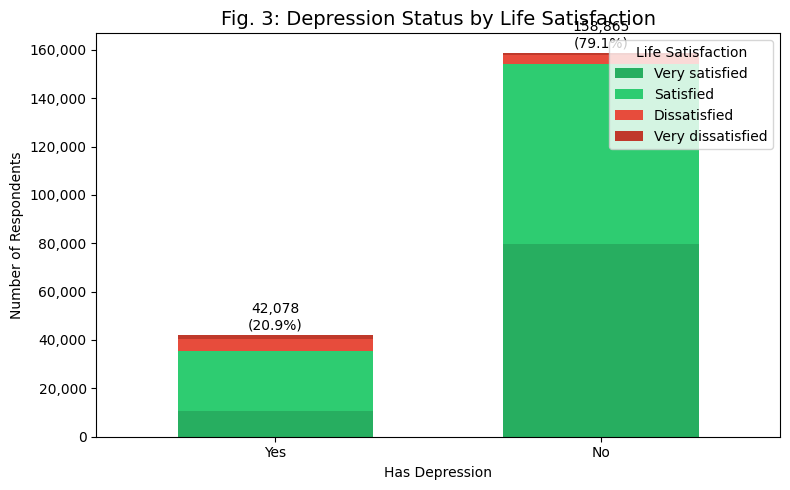

In [5]:
# ––––––– Depression by Life Satisfaction –––––––

import matplotlib.pyplot as plt

# Labels
depression_labels = {1: "Yes", 2: "No"}
life_satisfaction_labels = {
    1: "Very satisfied",
    2: "Satisfied",
    3: "Dissatisfied",
    4: "Very dissatisfied",
}

# Keep only valid responses
valid = df[
    df["has_depression"].isin([1, 2]) &
    df["life_satisfaction"].isin([1, 2, 3, 4])
].copy()

valid["has_depression"] = valid["has_depression"].map(depression_labels)
valid["life_satisfaction"] = valid["life_satisfaction"].map(life_satisfaction_labels)

# Crosstab counts (stack segments are life satisfaction; bars are depression yes/no)
ct = pd.crosstab(valid["has_depression"], valid["life_satisfaction"])

# Consistent ordering
ct = ct.reindex(index=["Yes", "No"])
ct = ct[["Very satisfied", "Satisfied", "Dissatisfied", "Very dissatisfied"]]

fig, ax = plt.subplots(figsize=(8, 5))

ct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.6,
    color=["#27ae60", "#2ecc71", "#e74c3c", "#c0392b"],  # green -> red
)

# Add total count + overall % labels above each bar
bar_totals = ct.sum(axis=1)
grand_total = bar_totals.sum()

for i, label in enumerate(ct.index):
    total = bar_totals.loc[label]
    pct = (total / grand_total) * 100
    ax.text(
        i,
        total + grand_total * 0.005,  # small offset relative to dataset size
        f"{total:,.0f}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("Fig. 3: Depression Status by Life Satisfaction", fontsize=14)
ax.set_xlabel("Has Depression")
ax.set_ylabel("Number of Respondents")
ax.legend(title="Life Satisfaction", loc="upper right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

The graph is hard to read so we do not create similar ones for emotional support and loneliness, but instead do those two and life satisfaction **analogously to Figure 2**

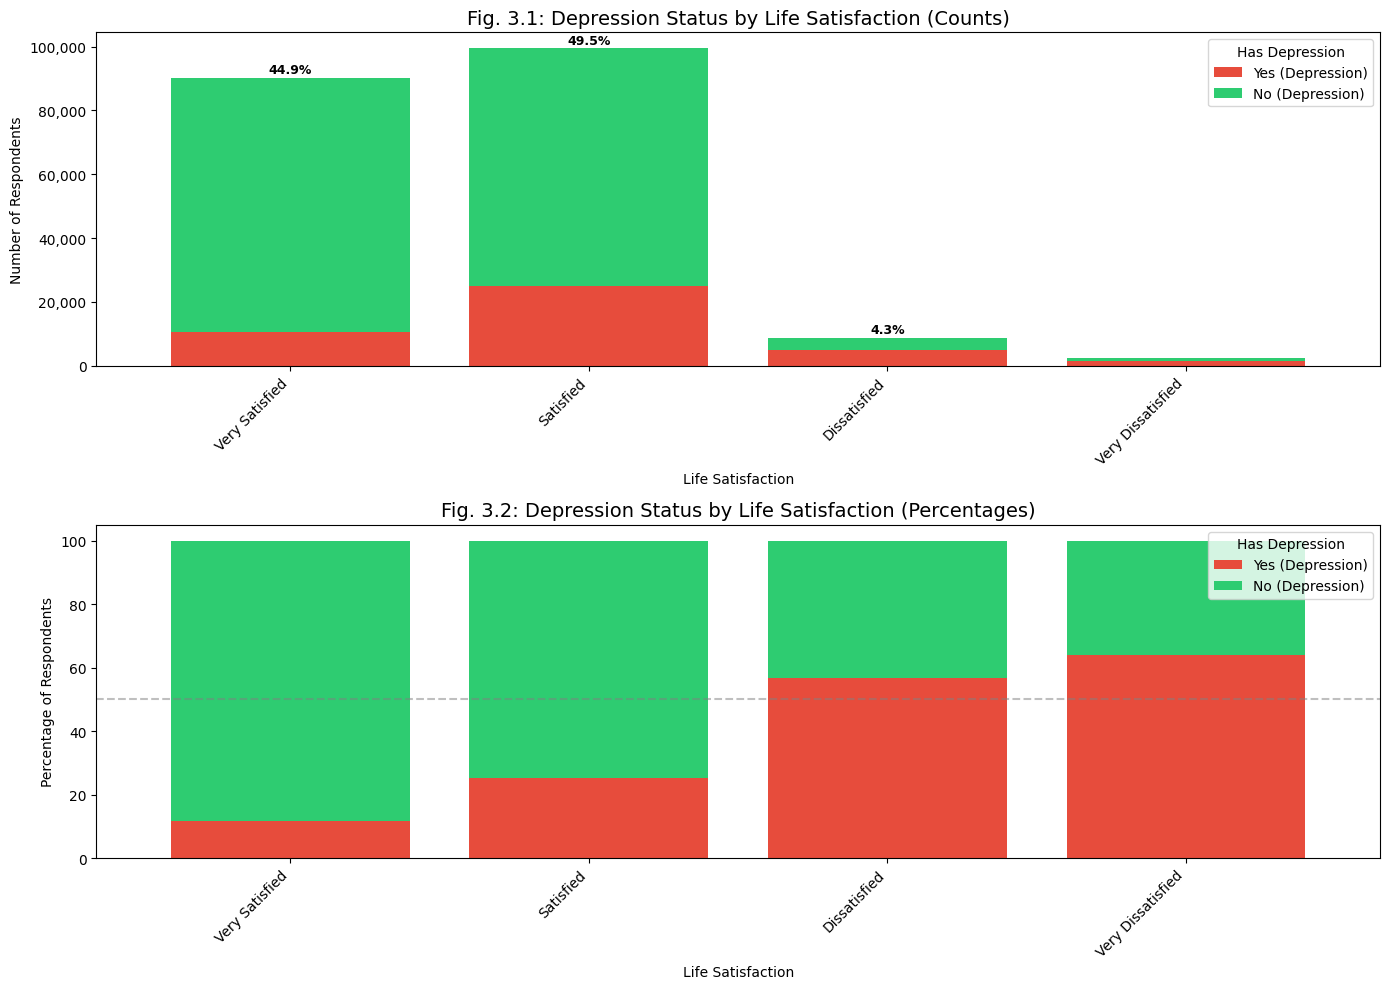

In [6]:
# ––––––– Life Satisfaction –––––––

# Filter to valid responses only (1-4)
valid_life_sat = df[df['life_satisfaction'].isin([1, 2, 3, 4])].copy()

# Filter to valid depression responses (1 = Yes, 2 = No)
valid_life_sat = valid_life_sat[valid_life_sat['has_depression'].isin([1, 2])]

# Create crosstabs
crosstab_counts = pd.crosstab(
    valid_life_sat['life_satisfaction'], 
    valid_life_sat['has_depression']
)
crosstab_pct = pd.crosstab(
    valid_life_sat['life_satisfaction'], 
    valid_life_sat['has_depression'],
    normalize='index'
) * 100

# Rename columns for clarity
crosstab_counts.columns = ['Yes (Depression)', 'No (Depression)']
crosstab_pct.columns = ['Yes (Depression)', 'No (Depression)']

# Map numeric codes to labels
life_sat_labels = {1: 'Very Satisfied', 2: 'Satisfied', 3: 'Dissatisfied', 4: 'Very Dissatisfied'}
crosstab_counts.index = crosstab_counts.index.map(life_sat_labels)
crosstab_pct.index = crosstab_pct.index.map(life_sat_labels)

# Calculate total responses and percentage for each value
total_responses = crosstab_counts.sum(axis=1)
pct_of_total = (total_responses / total_responses.sum()) * 100

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Counts
crosstab_counts.plot(
    kind='bar', 
    stacked=True, 
    ax=ax1, 
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax1.set_title('Fig. 3.1: Depression Status by Life Satisfaction (Counts)', fontsize=14)
ax1.set_xlabel('Life Satisfaction')
ax1.set_ylabel('Number of Respondents')
ax1.legend(title='Has Depression', loc='upper right')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add percentage labels to significant columns (e.g., >= 2% of total)
threshold = 2.0
for i, (cat, pct) in enumerate(pct_of_total.items()):
    if pct >= threshold:
        count = total_responses[cat]
        ax1.text(
            i, count + 500,
            f'{pct:.1f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

# Plot 2: Percentages
crosstab_pct.plot(
    kind='bar', 
    stacked=True, 
    ax=ax2, 
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax2.set_title('Fig. 3.2: Depression Status by Life Satisfaction (Percentages)', fontsize=14)
ax2.set_xlabel('Life Satisfaction')
ax2.set_ylabel('Percentage of Respondents')
ax2.legend(title='Has Depression', loc='upper right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

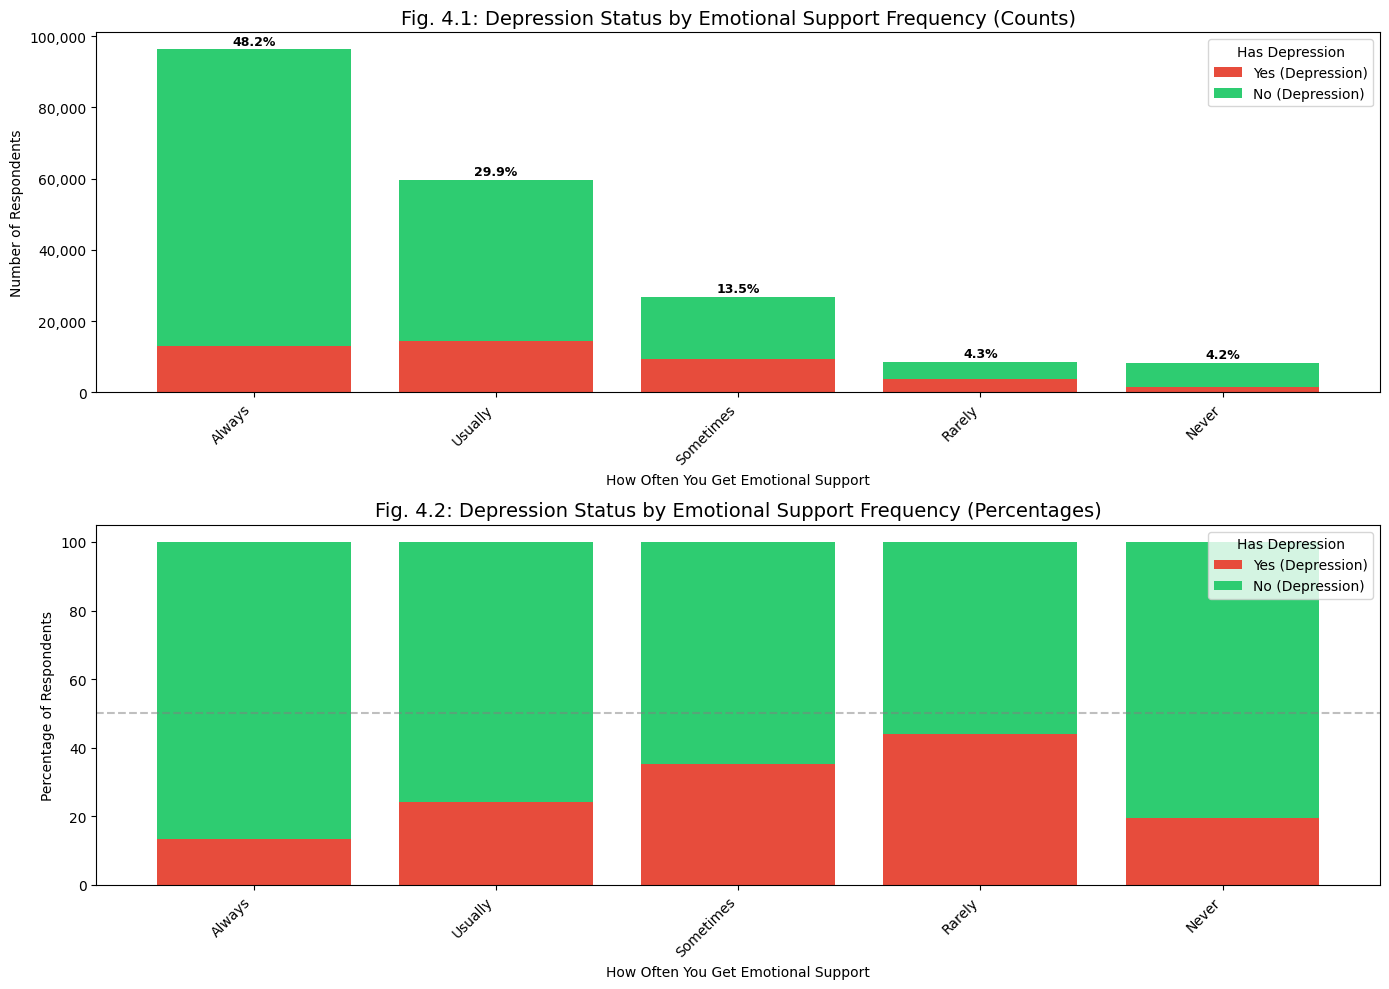

In [7]:
# ––––––– Emotional support –––––––

# Filter to valid responses only (1-5)
valid_emotional_support = df[df['emotional_support_freq'].isin([1, 2, 3, 4, 5])].copy()

# Filter to valid depression responses (1 = Yes, 2 = No)
valid_emotional_support = valid_emotional_support[valid_emotional_support['has_depression'].isin([1, 2])]

# Create crosstabs
crosstab_counts = pd.crosstab(
    valid_emotional_support['emotional_support_freq'], 
    valid_emotional_support['has_depression']
)
crosstab_pct = pd.crosstab(
    valid_emotional_support['emotional_support_freq'], 
    valid_emotional_support['has_depression'],
    normalize='index'
) * 100

# Rename columns for clarity
crosstab_counts.columns = ['Yes (Depression)', 'No (Depression)']
crosstab_pct.columns = ['Yes (Depression)', 'No (Depression)']

# Map numeric codes to labels
support_labels = {1: 'Always', 2: 'Usually', 3: 'Sometimes', 4: 'Rarely', 5: 'Never'}
crosstab_counts.index = crosstab_counts.index.map(support_labels)
crosstab_pct.index = crosstab_pct.index.map(support_labels)

# Calculate total responses and percentage for each value
total_responses = crosstab_counts.sum(axis=1)
pct_of_total = (total_responses / total_responses.sum()) * 100

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Counts
crosstab_counts.plot(
    kind='bar', 
    stacked=True, 
    ax=ax1, 
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax1.set_title('Fig. 4.1: Depression Status by Emotional Support Frequency (Counts)', fontsize=14)
ax1.set_xlabel('How Often You Get Emotional Support')
ax1.set_ylabel('Number of Respondents')
ax1.legend(title='Has Depression', loc='upper right')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add percentage labels to significant columns (e.g., >= 2% of total)
threshold = 2.0
for i, (cat, pct) in enumerate(pct_of_total.items()):
    if pct >= threshold:
        count = total_responses[cat]
        ax1.text(
            i, count + 500,
            f'{pct:.1f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

# Plot 2: Percentages
crosstab_pct.plot(
    kind='bar', 
    stacked=True, 
    ax=ax2, 
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax2.set_title('Fig. 4.2: Depression Status by Emotional Support Frequency (Percentages)', fontsize=14)
ax2.set_xlabel('How Often You Get Emotional Support')
ax2.set_ylabel('Percentage of Respondents')
ax2.legend(title='Has Depression', loc='upper right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

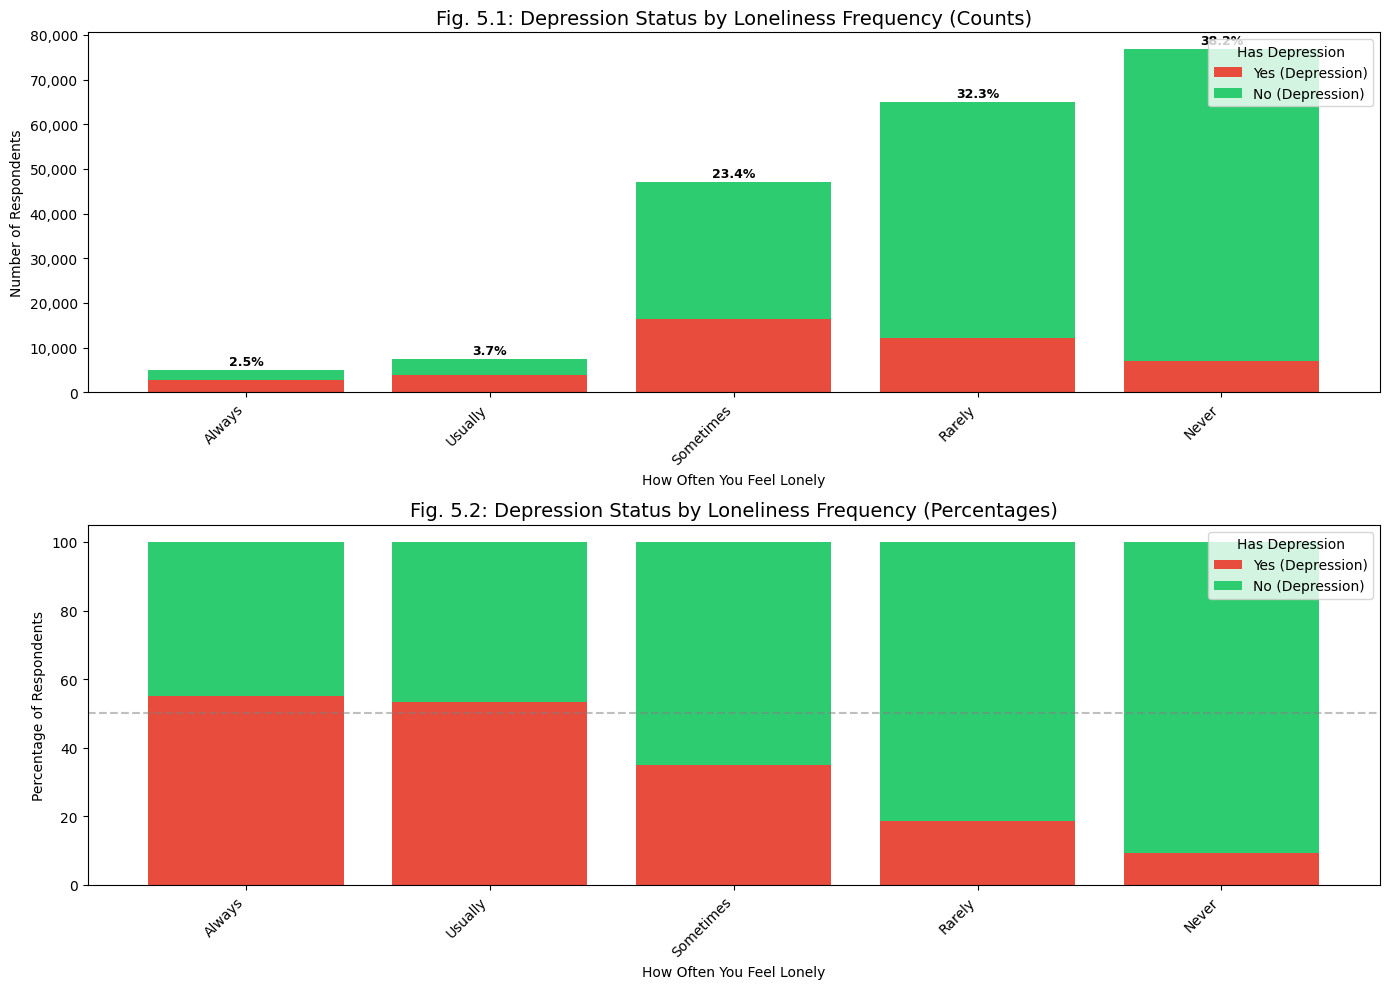

In [8]:
# ––––––– Loneliness –––––––

# Filter to valid responses only (1-5)
valid_loneliness = df[df['loneliness_freq'].isin([1, 2, 3, 4, 5])].copy()

# Filter to valid depression responses (1 = Yes, 2 = No)
valid_loneliness = valid_loneliness[valid_loneliness['has_depression'].isin([1, 2])]

# Create crosstabs
crosstab_counts = pd.crosstab(
    valid_loneliness['loneliness_freq'], 
    valid_loneliness['has_depression']
)
crosstab_pct = pd.crosstab(
    valid_loneliness['loneliness_freq'], 
    valid_loneliness['has_depression'],
    normalize='index'
) * 100

# Rename columns for clarity
crosstab_counts.columns = ['Yes (Depression)', 'No (Depression)']
crosstab_pct.columns = ['Yes (Depression)', 'No (Depression)']

# Map numeric codes to labels
loneliness_labels = {1: 'Always', 2: 'Usually', 3: 'Sometimes', 4: 'Rarely', 5: 'Never'}
crosstab_counts.index = crosstab_counts.index.map(loneliness_labels)
crosstab_pct.index = crosstab_pct.index.map(loneliness_labels)

# Calculate total responses and percentage for each value
total_responses = crosstab_counts.sum(axis=1)
pct_of_total = (total_responses / total_responses.sum()) * 100

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Counts
crosstab_counts.plot(
    kind='bar', 
    stacked=True, 
    ax=ax1, 
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax1.set_title('Fig. 5.1: Depression Status by Loneliness Frequency (Counts)', fontsize=14)
ax1.set_xlabel('How Often You Feel Lonely')
ax1.set_ylabel('Number of Respondents')
ax1.legend(title='Has Depression', loc='upper right')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add percentage labels to significant columns (e.g., >= 2% of total)
threshold = 2.0
for i, (cat, pct) in enumerate(pct_of_total.items()):
    if pct >= threshold:
        count = total_responses[cat]
        ax1.text(
            i, count + 500,
            f'{pct:.1f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

# Plot 2: Percentages
crosstab_pct.plot(
    kind='bar', 
    stacked=True, 
    ax=ax2, 
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax2.set_title('Fig. 5.2: Depression Status by Loneliness Frequency (Percentages)', fontsize=14)
ax2.set_xlabel('How Often You Feel Lonely')
ax2.set_ylabel('Percentage of Respondents')
ax2.legend(title='Has Depression', loc='upper right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 2.2 Mental health predictor findings (Life Satisfaction, Emotional Support, Loneliness)

Life satisfaction
1. As dissatisfaction increases so does the share of people with (prveious) depression
2. However the share of dissatisfied people is very low

Emotional support
1. Over 90% of respondents gets the emotional support they need at least sometimes
2. There is no clearly notable trend or correlation between emotional support and depression

Loneliness
1. Less than 30% of respondents feels lonely sometimes or more often
2. As the frequency of loneliness increases so does the share of respondents with (previous) depression.

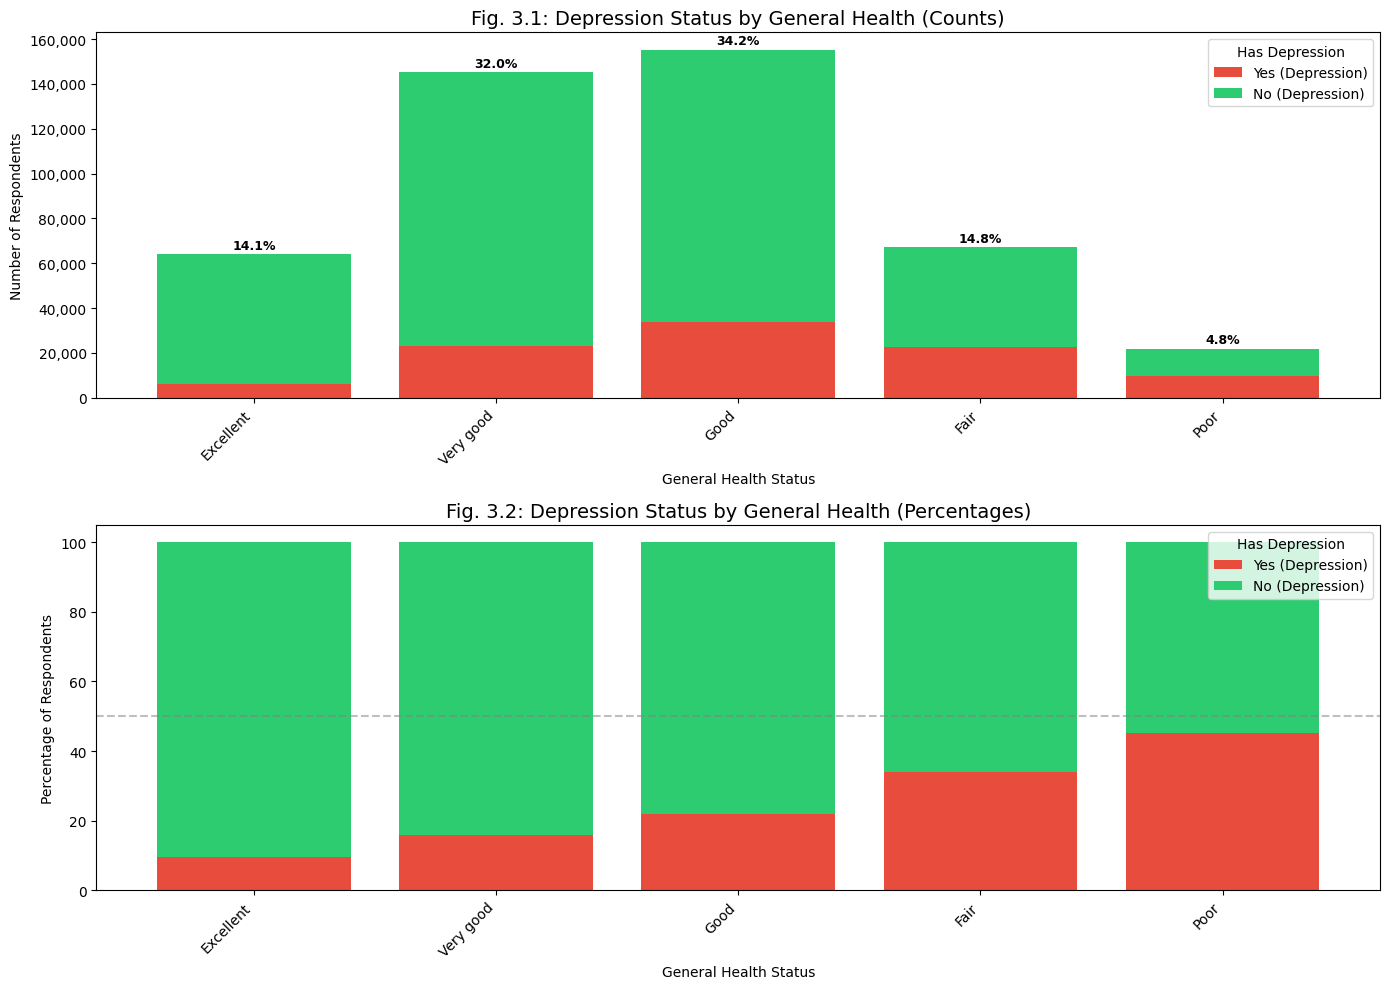

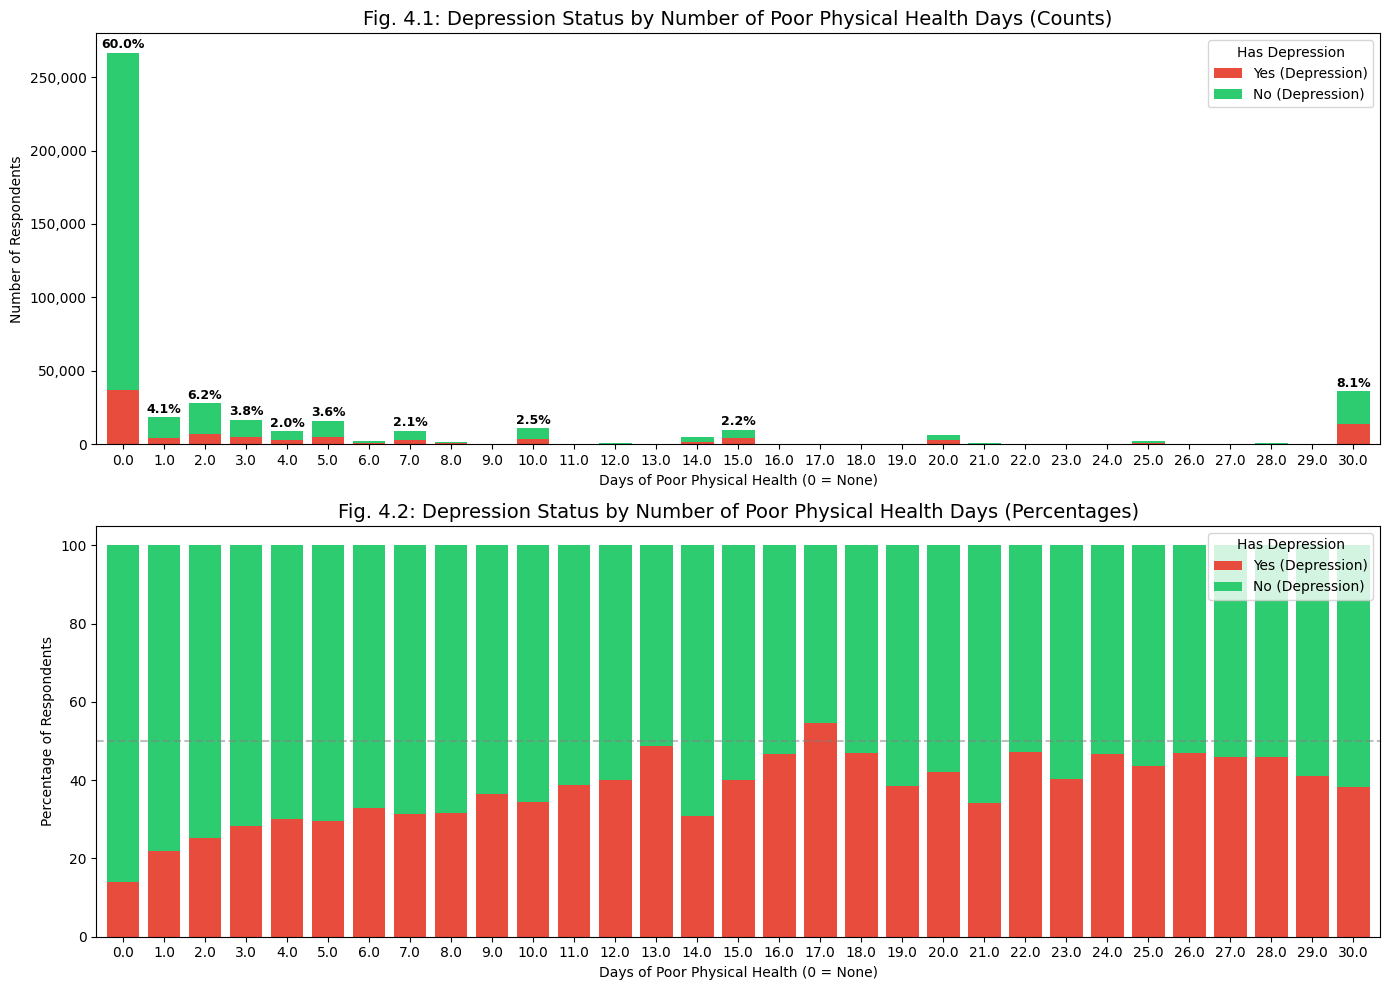

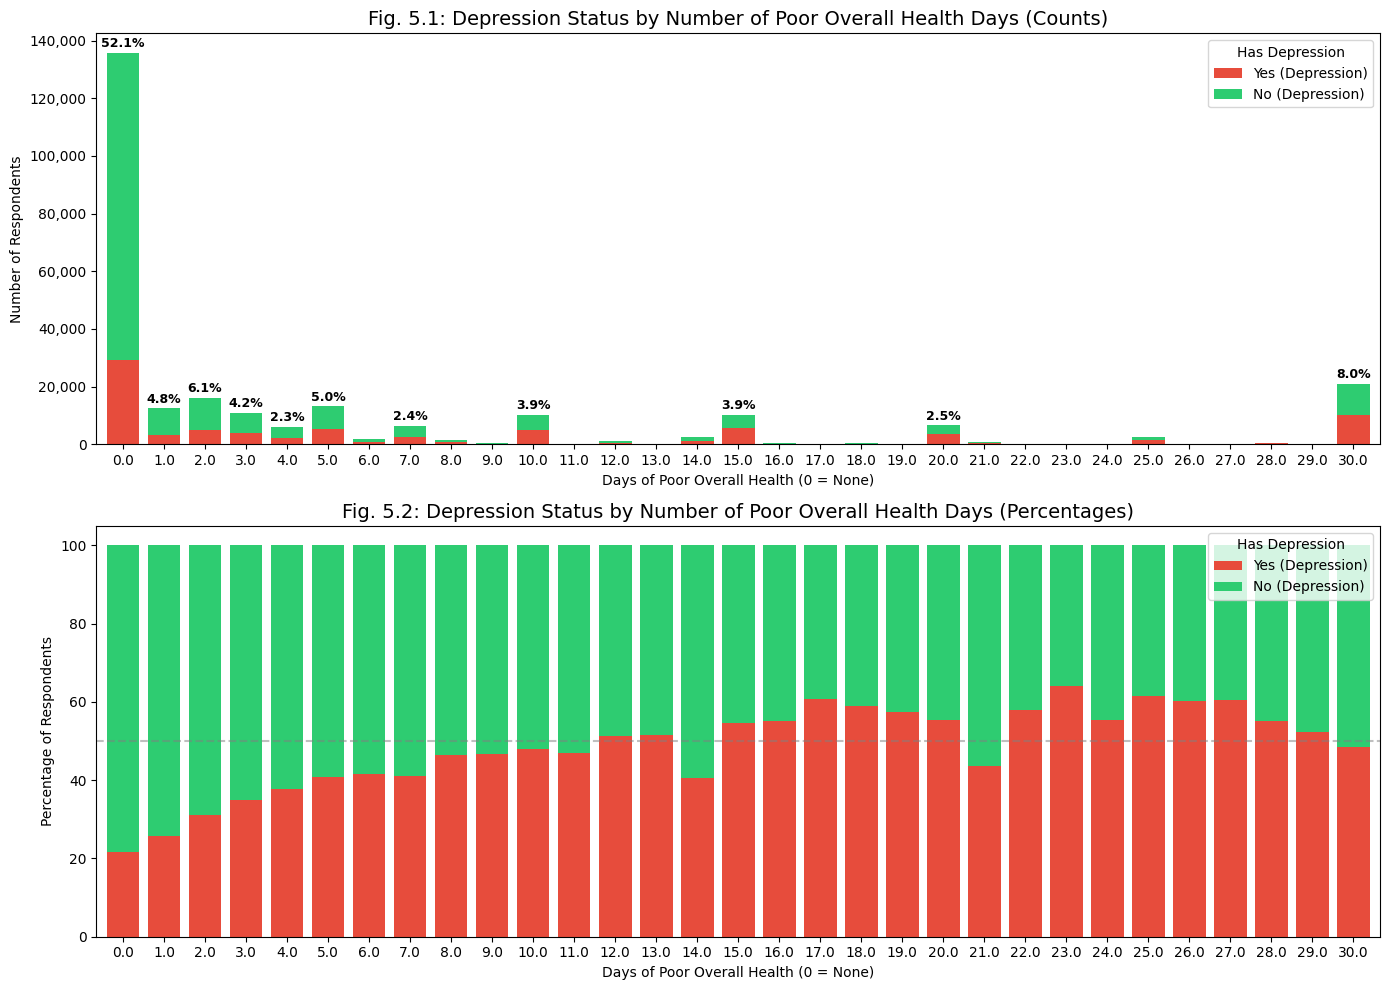

In [9]:
# ––––––– General health status variables –––––––

# 1. General Health
general_health_labels = {
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor",
    7: "Don't know/Not sure",
    9: "Refused"
}

valid_general_health = df[df['general_health'].isin([1, 2, 3, 4, 5])].copy()
valid_general_health = valid_general_health[valid_general_health['has_depression'].isin([1, 2])]

crosstab_general_health_counts = pd.crosstab(
    valid_general_health['general_health'].map(general_health_labels),
    valid_general_health['has_depression']
)
crosstab_general_health_pct = pd.crosstab(
    valid_general_health['general_health'].map(general_health_labels),
    valid_general_health['has_depression'],
    normalize='index'
) * 100

crosstab_general_health_counts.columns = ['Yes (Depression)', 'No (Depression)']
crosstab_general_health_pct.columns = ['Yes (Depression)', 'No (Depression)']

# Reorder to match the label order
label_order = ["Excellent", "Very good", "Good", "Fair", "Poor"]
crosstab_general_health_counts = crosstab_general_health_counts.reindex(label_order)
crosstab_general_health_pct = crosstab_general_health_pct.reindex(label_order)

total_responses_general = crosstab_general_health_counts.sum(axis=1)
pct_of_total_general = (total_responses_general / total_responses_general.sum()) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

crosstab_general_health_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax1.set_title('Fig. 3.1: Depression Status by General Health (Counts)', fontsize=14)
ax1.set_xlabel('General Health Status')
ax1.set_ylabel('Number of Respondents')
ax1.legend(title='Has Depression', loc='upper right')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

threshold = 2.0
for i, (health, pct) in enumerate(pct_of_total_general.items()):
    if pct >= threshold:
        count = total_responses_general[health]
        ax1.text(
            i, count + 1000,
            f'{pct:.1f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

crosstab_general_health_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax2.set_title('Fig. 3.2: Depression Status by General Health (Percentages)', fontsize=14)
ax2.set_xlabel('General Health Status')
ax2.set_ylabel('Percentage of Respondents')
ax2.legend(title='Has Depression', loc='upper right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Days of Poor Physical Health
valid_physical_health = df[df['days_poor_physical_health'].isin(list(range(1, 31)) + [88])].copy()
valid_physical_health['days_poor_physical_health'] = valid_physical_health['days_poor_physical_health'].replace(88, 0)
valid_physical_health = valid_physical_health[valid_physical_health['has_depression'].isin([1, 2])]

crosstab_physical_counts = pd.crosstab(
    valid_physical_health['days_poor_physical_health'],
    valid_physical_health['has_depression']
)
crosstab_physical_pct = pd.crosstab(
    valid_physical_health['days_poor_physical_health'],
    valid_physical_health['has_depression'],
    normalize='index'
) * 100

crosstab_physical_counts.columns = ['Yes (Depression)', 'No (Depression)']
crosstab_physical_pct.columns = ['Yes (Depression)', 'No (Depression)']

crosstab_physical_counts = crosstab_physical_counts.sort_index()
crosstab_physical_pct = crosstab_physical_pct.sort_index()

total_responses_physical = crosstab_physical_counts.sum(axis=1)
pct_of_total_physical = (total_responses_physical / total_responses_physical.sum()) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

crosstab_physical_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax1.set_title('Fig. 4.1: Depression Status by Number of Poor Physical Health Days (Counts)', fontsize=14)
ax1.set_xlabel('Days of Poor Physical Health (0 = None)')
ax1.set_ylabel('Number of Respondents')
ax1.legend(title='Has Depression', loc='upper right')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

threshold = 2.0
for i, (day, pct) in enumerate(pct_of_total_physical.items()):
    if pct >= threshold:
        count = total_responses_physical[day]
        ax1.text(
            i, count + 1000,
            f'{pct:.1f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

crosstab_physical_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax2.set_title('Fig. 4.2: Depression Status by Number of Poor Physical Health Days (Percentages)', fontsize=14)
ax2.set_xlabel('Days of Poor Physical Health (0 = None)')
ax2.set_ylabel('Percentage of Respondents')
ax2.legend(title='Has Depression', loc='upper right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. Days of Poor Overall Health
valid_overall_health = df[df['days_poor_health_overall'].isin(list(range(1, 31)) + [88])].copy()
valid_overall_health['days_poor_health_overall'] = valid_overall_health['days_poor_health_overall'].replace(88, 0)
valid_overall_health = valid_overall_health[valid_overall_health['has_depression'].isin([1, 2])]

crosstab_overall_counts = pd.crosstab(
    valid_overall_health['days_poor_health_overall'],
    valid_overall_health['has_depression']
)
crosstab_overall_pct = pd.crosstab(
    valid_overall_health['days_poor_health_overall'],
    valid_overall_health['has_depression'],
    normalize='index'
) * 100

crosstab_overall_counts.columns = ['Yes (Depression)', 'No (Depression)']
crosstab_overall_pct.columns = ['Yes (Depression)', 'No (Depression)']

crosstab_overall_counts = crosstab_overall_counts.sort_index()
crosstab_overall_pct = crosstab_overall_pct.sort_index()

total_responses_overall = crosstab_overall_counts.sum(axis=1)
pct_of_total_overall = (total_responses_overall / total_responses_overall.sum()) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

crosstab_overall_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax1.set_title('Fig. 5.1: Depression Status by Number of Poor Overall Health Days (Counts)', fontsize=14)
ax1.set_xlabel('Days of Poor Overall Health (0 = None)')
ax1.set_ylabel('Number of Respondents')
ax1.legend(title='Has Depression', loc='upper right')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

threshold = 2.0
for i, (day, pct) in enumerate(pct_of_total_overall.items()):
    if pct >= threshold:
        count = total_responses_overall[day]
        ax1.text(
            i, count + 1000,
            f'{pct:.1f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

crosstab_overall_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    color=['#e74c3c', '#2ecc71'],
    width=0.8
)
ax2.set_title('Fig. 5.2: Depression Status by Number of Poor Overall Health Days (Percentages)', fontsize=14)
ax2.set_xlabel('Days of Poor Overall Health (0 = None)')
ax2.set_ylabel('Percentage of Respondents')
ax2.legend(title='Has Depression', loc='upper right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 2.3 General Health Predictors

General health
1. Share of those with depression increases as general health declines
2. Over 80% of respondents report at least good health

Days of poor physical health
1. Once again 0 jumps out heavily, low numbers are prevalent, and so are numbers of days corresponding to easy fractions of the month
2. No clear trend in share of those with depression

Days of poor health overall:
1. Similar distribution of such days to poor mental and poor physical health
2. Again, no clear trend in share of those with depression 